In [2]:
import ast
import mglearn #library provided by amueller
import numpy as np
import seaborn as sns
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.feature_extraction import FeatureHasher
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
pd.options.display.float_format = '{:,.2g}'.format

In [3]:
df = pd.read_csv('games_steam.csv',low_memory=False)
df.shape

(94954, 44)

In [4]:
df.head()

,appid,name,release_date,required_age,price,dlc_count,detailed_description,about_the_game,short_description,reviews,...,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,discount,peak_ccu,tags,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent
0,7.3e+02,Counter-Strike 2,8/21/2012,0,0,1,"For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...",NaN,...,879,5174,350,0,1212356,"{'FPS': 90857, 'Shooter': 65397, 'Multiplayer'...",86,8632939,82,96473
1,5.8e+05,PUBG: BATTLEGROUNDS,12/21/2017,0,0,0,"LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...","LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...",Play PUBG: BATTLEGROUNDS for free. Land on str...,NaN,...,0,0,0,0,616738,"{'Survival': 14838, 'Shooter': 12727, 'Battle ...",59,2513842,68,16720
2,5.7e+02,Dota 2,7/9/2013,0,0,2,"The most-played game on Steam. Every day, mill...","The most-played game on Steam. Every day, mill...","Every day, millions of players worldwide enter...",“A modern multiplayer masterpiece.” 9.5/10 – D...,...,1536,898,892,0,555977,"{'Free to Play': 59933, 'MOBA': 20158, 'Multip...",81,2452595,80,29366
3,2.7e+05,Grand Theft Auto V Legacy,4/13/2015,17,0,0,"When a young street hustler, a retired bank ro...","When a young street hustler, a retired bank ro...",Grand Theft Auto V for PC offers players the o...,NaN,...,771,7101,74,0,117698,"{'Open World': 32644, 'Action': 23539, 'Multip...",87,1803832,92,17517
4,4.9e+05,Tom Clancy's Rainbow Six® Siege,12/1/2015,17,20,9,Edition Comparison Ultimate Edition The Tom Cl...,“One of the best first-person shooters ever ma...,"Tom Clancy's Rainbow Six® Siege is an elite, t...",NaN,...,0,0,0,0,0,"{'FPS': 8082, 'Multiplayer': 6139, 'Tactical':...",84,1168404,76,13017


In [5]:
print(df.columns)

Index(['appid', 'name', 'release_date', 'required_age', 'price', 'dlc_count',
       'detailed_description', 'about_the_game', 'short_description',
       'reviews', 'header_image', 'website', 'support_url', 'support_email',
       'windows', 'mac', 'linux', 'metacritic_score', 'achievements',
       'recommendations', 'supported_languages', 'full_audio_languages',
       'packages', 'developers', 'publishers', 'categories', 'genres',
       'screenshots', 'movies', 'user_score', 'positive', 'negative',
       'estimated_owners', 'average_playtime_forever',
       'average_playtime_2weeks', 'median_playtime_forever',
       'median_playtime_2weeks', 'discount', 'peak_ccu', 'tags',
       'pct_pos_total', 'num_reviews_total', 'pct_pos_recent',
       'num_reviews_recent'],
      dtype='str')


In [6]:
df.dtypes


appid                       float64
name                            str
release_date                    str
required_age                float64
price                       float64
dlc_count                   float64
detailed_description            str
about_the_game                  str
short_description               str
reviews                         str
header_image                    str
website                         str
support_url                     str
support_email                   str
windows                         str
mac                             str
linux                           str
metacritic_score                str
achievements                    str
recommendations                 str
supported_languages             str
full_audio_languages            str
packages                        str
developers                      str
publishers                      str
categories                      str
genres                          str
screenshots                 

## III. Checking Missing Values

Before training regression models, the dataset must be checked for missing values. Missing values may affect the training process and lead to unreliable results.

In [7]:
df.isna().sum()

appid                          10
name                           13
release_date                   11
required_age                   11
price                          11
dlc_count                      11
detailed_description         5436
about_the_game               5460
short_description            5359
reviews                     84523
header_image                   10
website                     53762
support_url                 50771
support_email               16105
windows                         7
mac                             6
linux                           6
metacritic_score                6
achievements                    6
recommendations                 5
supported_languages          5416
full_audio_languages        55093
packages                    19079
developers                   5455
publishers                   5784
categories                   5911
genres                       5445
screenshots                  3457
movies                       7669
user_score    

## IV. Data Cleaning

The dataset is cleaned to make it suitable for regression modeling.

The following cleaning steps are performed:
- removing unnecessary columns
- trimming extra spaces from column names and values
- removing dirty text patterns and symbols
- dropping rows with remaining missing values after cleaning



In [8]:
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df.isna().sum()

appid                          10
name                           13
release_date                   11
required_age                   11
price                          11
dlc_count                      11
detailed_description         5436
about_the_game               5460
short_description            5359
reviews                     84523
header_image                   10
website                     53762
support_url                 50771
support_email               16105
windows                         7
mac                             6
linux                           6
metacritic_score                6
achievements                    6
recommendations                 5
supported_languages          5416
full_audio_languages        55093
packages                    19079
developers                   5455
publishers                   5784
categories                   5911
genres                       5445
screenshots                  3457
movies                       7669
user_score    

In [9]:
print(df.shape)

(94954, 44)


In [10]:
df_clean = df.copy()

# Remove extra spaces from column names
df_clean.columns = df_clean.columns.str.strip()

# Remove columns with too many missing values (> 20,000 NaNs)
# This helps improve data quality by dropping features that are
# too sparse to be useful for analysis or machine learning.
# Rows are NOT affected.
threshold = 20000
df_clean = df_clean.loc[:, df.isna().sum() <= threshold]

# Drop Colunms because it is not relevant
cols_to_drop = [
    "appid",
    "screenshots",
    "about_the_game",
    "short_description",
    "website",
    "support_url",
    "support_email",
    "movies",
    "header_image",
    "release_date",
    "detailed_description",
    "header_image",
    "packages",
    "average_playtime_2weeks ",
    "median_playtime_forever",
    "median_playtime_2weeks",
    "positive",
    "negative",
    "pct_pos_total",
    "pct_pos_recent",
    "num_reviews_total",
    "num_reviews_recent",
    "peak_ccu",
    "recommendations",
]

df_clean = df_clean.drop(columns=cols_to_drop, errors="ignore")


def clean_numeric_series(series):
    return pd.to_numeric(
        series.astype(str)
        .str.strip()
        .str.replace(r"^id_", "", regex=True)
        .str.replace(r"_x$", "", regex=True)
        .str.replace("$", "", regex=False)
        .str.replace("%", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.replace("abc", "", regex=False)
        .replace("nan", np.nan),
        errors="coerce"
    )

numeric_cols = df_clean.select_dtypes(include=np.number).columns

df_clean[numeric_cols] = df_clean[numeric_cols].fillna(
    df_clean[numeric_cols].median()
)

print("Shape after cleaning and conversion:", df_clean.shape)
print("\nMissing values after conversion:\n")
print(df_clean.isnull().sum().sort_values(ascending=False).head(20))



Shape after cleaning and conversion: (94954, 19)

Missing values after conversion:

categories                  5911
publishers                  5784
developers                  5455
genres                      5445
supported_languages         5416
name                          13
windows                        7
linux                          6
metacritic_score               6
achievements                   6
mac                            6
average_playtime_2weeks        4
average_playtime_forever       4
estimated_owners               4
user_score                     4
discount                       4
required_age                   0
price                          0
dlc_count                      0
dtype: int64


In [11]:
df_clean = df_clean.dropna()

print("Final cleaned shape:", df_clean.shape)
print("\nRemaining missing values:\n")
print(df_clean.isnull().sum().sort_values(ascending=False).head(20))


Final cleaned shape: (88131, 19)

Remaining missing values:

name                        0
required_age                0
price                       0
dlc_count                   0
windows                     0
mac                         0
linux                       0
metacritic_score            0
achievements                0
supported_languages         0
developers                  0
publishers                  0
categories                  0
genres                      0
user_score                  0
estimated_owners            0
average_playtime_forever    0
average_playtime_2weeks     0
discount                    0
dtype: int64


In [12]:
print(df_clean.columns)

Index(['name', 'required_age', 'price', 'dlc_count', 'windows', 'mac', 'linux',
       'metacritic_score', 'achievements', 'supported_languages', 'developers',
       'publishers', 'categories', 'genres', 'user_score', 'estimated_owners',
       'average_playtime_forever', 'average_playtime_2weeks', 'discount'],
      dtype='str')


### Converting values

In [13]:
bool_cols = ["windows", "mac", "linux"]

# convert true and false values to 1's and 0's
df_clean[bool_cols] = df_clean[bool_cols].apply(
    lambda col: col.astype(str).str.strip().str.upper().map({
        "TRUE": 1,
        "FALSE": 0
    })
)

In [14]:
list_cols = ["supported_languages", "developers", "publishers", "categories", "genres"]

for col in list_cols:
    df_clean[col] = df_clean[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

In [15]:
mlb = MultiLabelBinarizer()

lang_encoded = mlb.fit_transform(df_clean["supported_languages"])

lang_df = pd.DataFrame(lang_encoded, columns=[f"lang_{c}" for c in mlb.classes_])

df_clean = df_clean.join(lang_df)

In [16]:
top_devs = df_clean["developers"].explode().value_counts().head(100).index

df_clean["developers_filtered"] = df_clean["developers"].apply(
    lambda x: [i for i in x if i in top_devs]
)

mlb = MultiLabelBinarizer()
dev_encoded = mlb.fit_transform(df_clean["developers_filtered"])

dev_df = pd.DataFrame(dev_encoded, columns=[f"dev_{c}" for c in mlb.classes_], index=df_clean.index)

df_clean = pd.concat([df_clean, dev_df], axis=1)

In [17]:
top_pub = df_clean["publishers"].explode().value_counts().head(100).index

df_clean["publishers_filtered"] = df_clean["publishers"].apply(
    lambda x: [i for i in x if i in top_pub]
)

mlb_pub = MultiLabelBinarizer()

pub_encoded = mlb_pub.fit_transform(df_clean["publishers_filtered"])

pub_df = pd.DataFrame(
    pub_encoded,
    columns=[f"pub_{c}" for c in mlb_pub.classes_],
    index=df_clean.index
)

df_clean = pd.concat([df_clean, pub_df], axis=1)

In [18]:
mlb_cat = MultiLabelBinarizer()

cat_encoded = mlb_cat.fit_transform(df_clean["categories"])

cat_df = pd.DataFrame(
    cat_encoded,
    columns=[f"cat_{c}" for c in mlb_cat.classes_],
    index=df_clean.index
)

df_clean = pd.concat([df_clean, cat_df], axis=1)

In [19]:
mlb_gen = MultiLabelBinarizer()

gen_encoded = mlb_gen.fit_transform(df_clean["genres"])

gen_df = pd.DataFrame(
    gen_encoded,
    columns=[f"genre_{c}" for c in mlb_gen.classes_],
    index=df_clean.index
)

df_clean = pd.concat([df_clean, gen_df], axis=1)

In [20]:
df_clean = df_clean.drop(columns=["supported_languages", "developers", "publishers", "categories", "genres"])

In [21]:
df_clean

,name,required_age,price,dlc_count,windows,mac,linux,metacritic_score,achievements,user_score,...,genre_Short,genre_Simulation,genre_Software Training,genre_Sports,genre_Strategy,genre_Tutorial,genre_Utilities,genre_Video Production,genre_Violent,genre_Web Publishing
0,Counter-Strike 2,0,0,1,1,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,PUBG: BATTLEGROUNDS,0,0,0,1,0,0,0,37,0,...,0,0,0,0,0,0,0,0,0,0
2,Dota 2,0,0,2,1,1,1,90,0,0,...,0,0,0,0,1,0,0,0,0,0
3,Grand Theft Auto V Legacy,17,0,0,1,0,0,96,77,0,...,0,0,0,0,0,0,0,0,0,0
4,Tom Clancy's Rainbow Six® Siege,17,20,9,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94949,Outrun Them,0,4,0,1,0,0,0,6,0,...,0,0,0,0,0,0,0,0,0,0
94950,Lands of Pharaoh: Episode 1,0,10,0,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
94951,Player One,0,2,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
94952,DragonRoad,0,30,0,1,0,0,0,34,0,...,0,1,0,0,1,0,0,0,0,0


In [22]:
df_clean.dtypes

name                          str
required_age              float64
price                     float64
dlc_count                 float64
windows                     int64
                           ...   
genre_Tutorial              int64
genre_Utilities             int64
genre_Video Production      int64
genre_Violent               int64
genre_Web Publishing        int64
Length: 396, dtype: object

## V. Correlation 
To visualize the strength and direction of relationships among the variables, we use the correlation heatmap.


) missing from font(s) DejaVu Sans.ms\Python\Python314\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 13 (
  fig.canvas.draw()
) missing from font(s) DejaVu Sans.ms\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


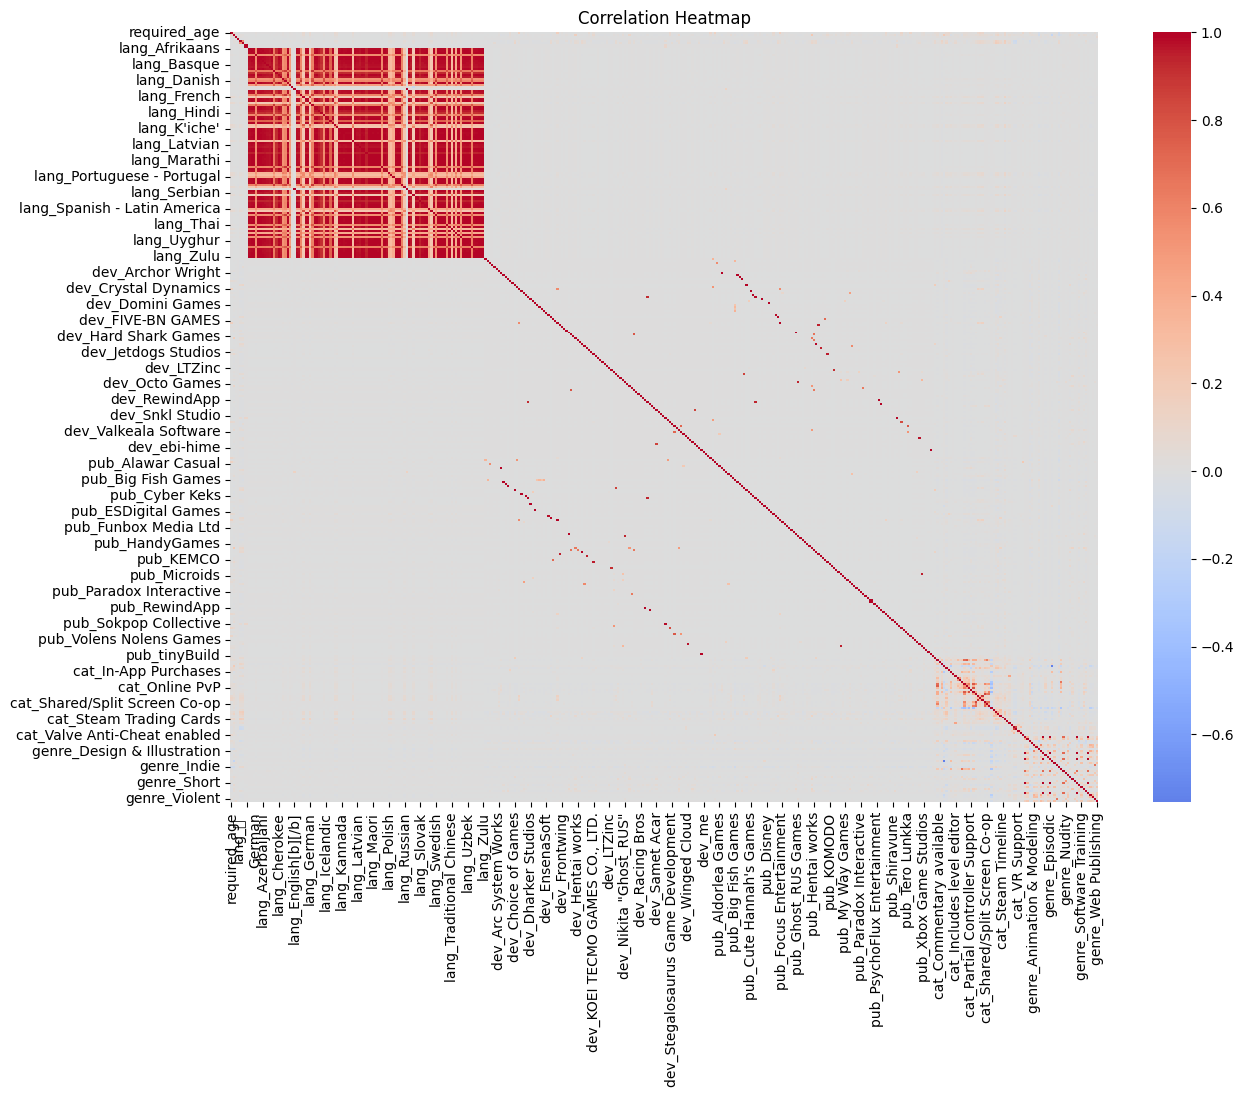

In [23]:
plt.figure(figsize=(14, 10))
sns.heatmap(df_clean.corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()


The correlation analysis shows that many variables are still highly correlated with each other, particularly those derived from similar financial indicators such as Open, High, Low, Close, and related features across different indices.



In [24]:
numeric_df = df_clean.select_dtypes(include=['number'])

corr_matrix = numeric_df.corr()
threshold = 0.9

print("Strongly Correlated Feature Pairs:\n")

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        corr_value = corr_matrix.iloc[i, j]

        if corr_value > threshold or corr_value < -threshold:
            col1 = corr_matrix.columns[i]
            col2 = corr_matrix.columns[j]
            print(f"{col1} <--> {col2} : {corr_value:.2f}")

Strongly Correlated Feature Pairs:

lang_
French <--> lang_
German : 1.00
lang_Afrikaans <--> lang_Albanian : 0.98
lang_Afrikaans <--> lang_Amharic : 0.98
lang_Afrikaans <--> lang_Armenian : 0.98
lang_Afrikaans <--> lang_Assamese : 0.98
lang_Afrikaans <--> lang_Azerbaijani : 0.98
lang_Afrikaans <--> lang_Bangla : 0.97
lang_Afrikaans <--> lang_Basque : 0.97
lang_Afrikaans <--> lang_Belarusian : 0.97
lang_Afrikaans <--> lang_Bosnian : 0.98
lang_Afrikaans <--> lang_Catalan : 0.93
lang_Afrikaans <--> lang_Cherokee : 0.98
lang_Afrikaans <--> lang_Croatian : 0.96
lang_Afrikaans <--> lang_Dari : 0.98
lang_Afrikaans <--> lang_Estonian : 0.98
lang_Afrikaans <--> lang_Filipino : 0.96
lang_Afrikaans <--> lang_Galician : 0.98
lang_Afrikaans <--> lang_Georgian : 0.98
lang_Afrikaans <--> lang_Gujarati : 0.98
lang_Afrikaans <--> lang_Hausa : 0.98
lang_Afrikaans <--> lang_Hebrew : 0.96
lang_Afrikaans <--> lang_Hindi : 0.91
lang_Afrikaans <--> lang_Icelandic : 0.98
lang_Afrikaans <--> lang_Igbo : 0.99


In [25]:
df_model = df_clean.copy()

In [26]:
print(df_model['average_playtime_forever'].dtype)

str


In [27]:
# Separate target
target_col = "average_playtime_forever"

# Ensure the target is numeric before filtering
df_model[target_col] = pd.to_numeric(df_model[target_col], errors='coerce')
df_model = df_model.dropna(subset=[target_col])

# Filter out zero-playtime rows — they're noise, not signal
df_model = df_model[df_model[target_col] > 0]

# log-transform the remaining non-zero values
df_model[target_col] = np.log1p(df_model[target_col])

# Keep only numeric columns
df_model = df_model.select_dtypes(include=['number'])
df_model = df_model.dropna()

# Compute correlation matrix
corr_matrix = df_model.corr().abs()

# Upper triangle (avoid duplicate pairs)
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

threshold = 0.9

to_drop = []

for column in upper.columns:
    for row in upper.index:
        if (upper.loc[row, column] > threshold and column != target_col and row != target_col):
            to_drop.append(column)
            break

# Drop highly correlated columns
df_model = df_model.drop(columns=set(to_drop))

print("Dropped columns:")
print(to_drop)

print("\nNew shape:", df_model.shape)

Dropped columns:
['lang_\r\nGerman', 'lang_Albanian', 'lang_Amharic', 'lang_Armenian', 'lang_Assamese', 'lang_Azerbaijani', 'lang_Bangla', 'lang_Basque', 'lang_Bosnian', 'lang_Cherokee', 'lang_Dari', 'lang_Estonian', 'lang_Filipino', 'lang_Galician', 'lang_Georgian', 'lang_Gujarati', 'lang_Hausa', 'lang_Hebrew', 'lang_Icelandic', 'lang_Igbo', 'lang_Irish', "lang_K'iche'", 'lang_Kannada', 'lang_Kazakh', 'lang_Khmer', 'lang_Kinyarwanda', 'lang_Konkani', 'lang_Kyrgyz', 'lang_Latvian', 'lang_Lithuanian', 'lang_Luxembourgish', 'lang_Macedonian', 'lang_Malay', 'lang_Malayalam', 'lang_Maltese', 'lang_Maori', 'lang_Marathi', 'lang_Mongolian', 'lang_Nepali', 'lang_Odia', 'lang_Persian', 'lang_Punjabi (Gurmukhi)', 'lang_Punjabi (Shahmukhi)', 'lang_Quechua', 'lang_Scots', 'lang_Serbian', 'lang_Sindhi', 'lang_Sinhala', 'lang_Slovenian', 'lang_Sorani', 'lang_Sotho', 'lang_Swahili', 'lang_Tajik', 'lang_Tamil', 'lang_Tatar', 'lang_Telugu', 'lang_Tigrinya', 'lang_Tswana', 'lang_Turkmen', 'lang_Urdu', 

Again, with threshold of 0.9, let's check the highly correlated pairs:

In [28]:
numeric_df = df_model.select_dtypes(include=['number'])

corr_matrix = numeric_df.corr()
threshold = 0.9

print("Strongly Correlated Feature Pairs:\n")

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        corr_value = corr_matrix.iloc[i, j]

        if corr_value > threshold or corr_value < -threshold:
            col1 = corr_matrix.columns[i]
            col2 = corr_matrix.columns[j]
            print(f"{col1} <--> {col2} : {corr_value:.2f}")


Strongly Correlated Feature Pairs:



) missing from font(s) DejaVu Sans.ms\Python\Python314\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 13 (
  fig.canvas.draw()
) missing from font(s) DejaVu Sans.ms\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


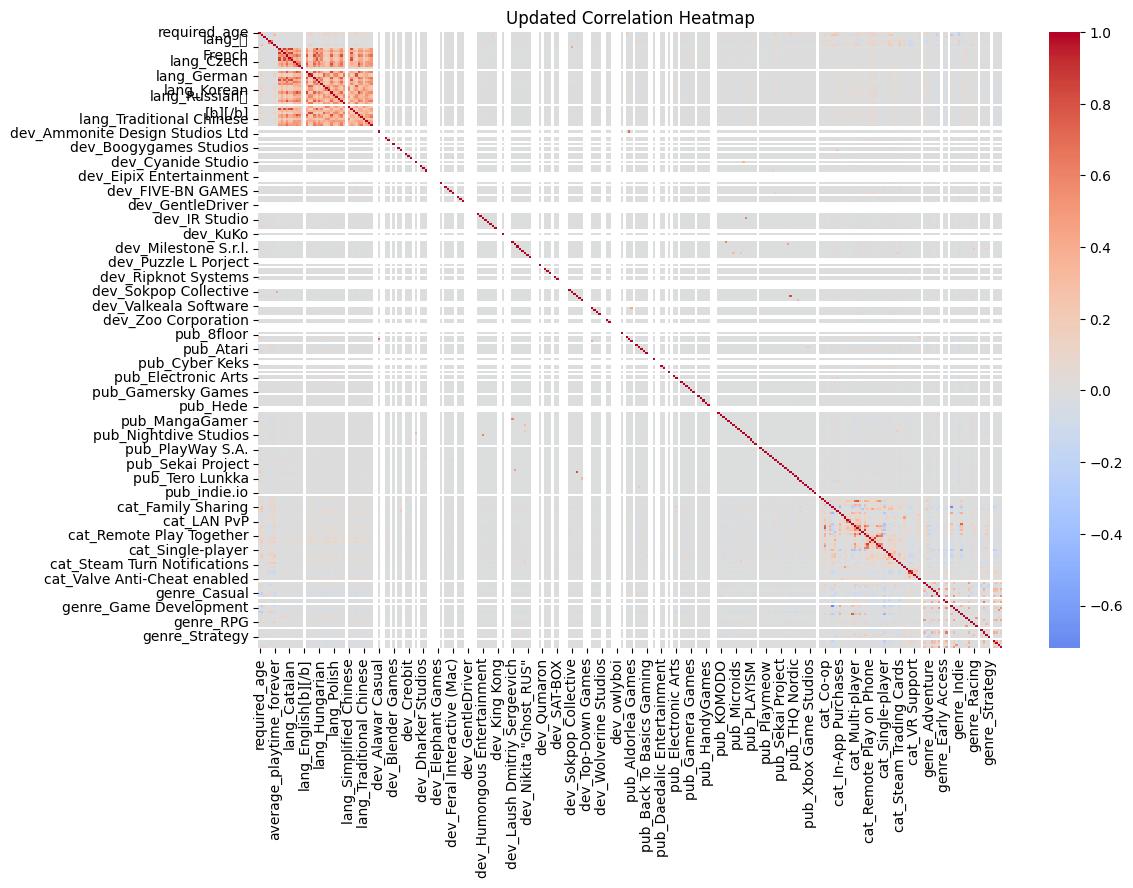

In [29]:
plt.figure(figsize=(12, 8))
sns.heatmap(df_model.corr(), cmap="coolwarm", center=0)
plt.title("Updated Correlation Heatmap")
plt.show()

In [31]:
print(df_model.columns)

Index(['required_age', 'price', 'dlc_count', 'windows', 'mac', 'linux',
       'average_playtime_forever', 'lang_\r\nFrench', 'lang_Afrikaans',
       'lang_Arabic',
       ...
       'genre_Short', 'genre_Simulation', 'genre_Software Training',
       'genre_Sports', 'genre_Strategy', 'genre_Tutorial', 'genre_Utilities',
       'genre_Video Production', 'genre_Violent', 'genre_Web Publishing'],
      dtype='str', length=300)


## VI. Normalization and Identifying the target
Min-Max normalization was applied to the dataset by first converting the cleaned and reduced dataset into a NumPy array and then scaling it using the MinMaxScaler.

The normalized values were then converted back into a DataFrame with the original column names preserved.

After normalization, the predictor variables and the target variable were separated. The target variable is **average_playtime_forever**, while the remaining columns were used as predictor features.

This ensures that all features are on a comparable scale before applying regression models.

In [32]:
mms = MinMaxScaler()
ex = np.array(df_model)

X_norm = mms.fit_transform(ex)

df_norm = pd.DataFrame(X_norm)
df_norm.columns = df_model.columns

X = df_norm.drop(columns=['average_playtime_forever'])
y = df_norm['average_playtime_forever']

## VII. K-Nearest Neighbors (KNN) Regressio

In [33]:
# Target variable
y = df_model['average_playtime_forever']

# Features
X = df_model.drop(columns=['average_playtime_forever'])

### Splitting the Dataset

The dataset is divided into training and testing sets. The training set is used to train the model, while the testing set is used to evaluate its performance.

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Creating and Training the KNN Regression Model

In [42]:
knn = KNeighborsRegressor(n_neighbors=5)

# Train the model
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

### Evaluating the Model

In [37]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Display results
print("KNN Regression Results")
print("-----------------------")
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

KNN Regression Results
-----------------------
MAE: 1.2694
MSE: 2.7263
RMSE: 1.6512
R² Score: 0.1589


### Finding the best k value

In [38]:
rmse_values = []
k_values = range(1, 21)

for k in k_values:
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    rmse_values.append(rmse)

# Display RMSE for each K value
for k, error in zip(k_values, rmse_values):
    print(f"K = {k}, RMSE = {error:.4f}")

K = 1, RMSE = 2.0835
K = 2, RMSE = 1.8231
K = 3, RMSE = 1.7493
K = 4, RMSE = 1.6829
K = 5, RMSE = 1.6512
K = 6, RMSE = 1.6406
K = 7, RMSE = 1.6393
K = 8, RMSE = 1.6243
K = 9, RMSE = 1.6104
K = 10, RMSE = 1.6000
K = 11, RMSE = 1.5923
K = 12, RMSE = 1.5915
K = 13, RMSE = 1.5897
K = 14, RMSE = 1.5799
K = 15, RMSE = 1.5801
K = 16, RMSE = 1.5823
K = 17, RMSE = 1.5839
K = 18, RMSE = 1.5800
K = 19, RMSE = 1.5799
K = 20, RMSE = 1.5825


### Visualizing the best k value

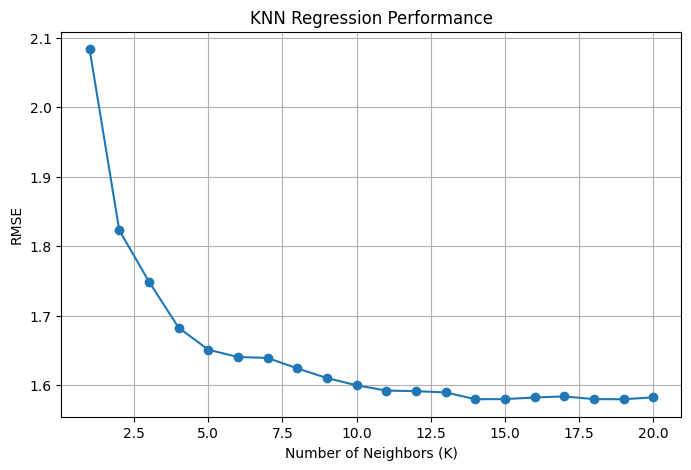

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(k_values, rmse_values, marker='o')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('RMSE')
plt.title('KNN Regression Performance')
plt.grid(True)
plt.show()

### Conclusion

The K-Nearest Neighbors (KNN) Regression model was successfully implemented to predict average_playtime_forever. Based on the evaluation results, the model achieved an MAE of 1.2694, an RMSE of 1.6512, and an R² score of 0.1589. These results indicate that the model was able to make predictions with moderate accuracy, although the low R² score suggests that the model still has limited ability to fully explain the variation in the target variable.

Different K values were tested to determine the optimal number of neighbors. The results showed that the RMSE gradually decreased as the value of K increased, reaching the lowest RMSE value around K = 14 to K = 19. This suggests that using more neighbors improved the stability and predictive performance of the model.

Overall, the KNN Regression model demonstrated that it can be used to estimate game playtime behavior, and selecting an appropriate K value is important for achieving better prediction performance. Future improvements may include feature engineering, hyperparameter tuning, or trying other regression algorithms to increase prediction accuracy.